# Midterm 2 - Questions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pygsp

plt.rcParams['text.usetex'] = True

## **Question 1.** The spectral content of a signal indicates if the signal is low-pass, band-pass, or high-pass. Again, intuition transfers from classical Fourier analysis.

### 1) Build a sensor graph by G = pygsp.graphs.Sensor(N=100, seed=1).

In [3]:
G = pygsp.graphs.Sensor(N= 100, seed= 1)

### 2) Compute its graph Fourier basis.

In [4]:
G.compute_fourier_basis()

### 3) Create two kinds of graph signals by following these steps:
1. Start by generating random signals of size 1 for each node in the graph according to the normal
distribution.
1. Generate two different filter banks of Heat kernels
characterized by their respective parameters,
specifically scale = 0 for the first filter and scale = 10 for the second filter. These parameters are
chosen to alter the filter’s behavior, leading to different spectral characteristics of the processed
signals.
1. Apply the defined filters to the randomly generated signals. This process will create two distinct
types of graph signals: one demonstrating low-pass characteristics and the other high-pass
characteristics.

In [5]:
# a)
s = np.random.randn(G.N)

# b)
g0 = pygsp.filters.Heat(G, tau= 0)
g10 = pygsp.filters.Heat(G, tau= 10)

# c)
s0 = g0.filter(s)
s10 = g10.filter(s)

### 4) Calculate the graph Fourier transform for the low-pass and high-pass graph signals to obtain the signal in the Graph Fourier domain $\hat{\boldsymbol{x}}$.

In [6]:
s0_ft = G.gft(s0)
s10_ft = G.gft(s10)

### 5) Plot the graph spectral content of $\hat{\boldsymbol{x}}$, i.e. $|\hat{\boldsymbol{x}}|$

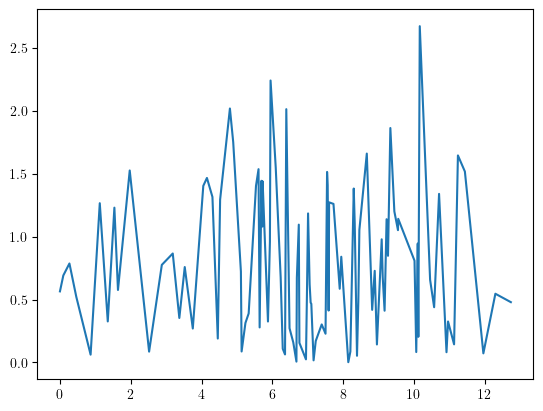

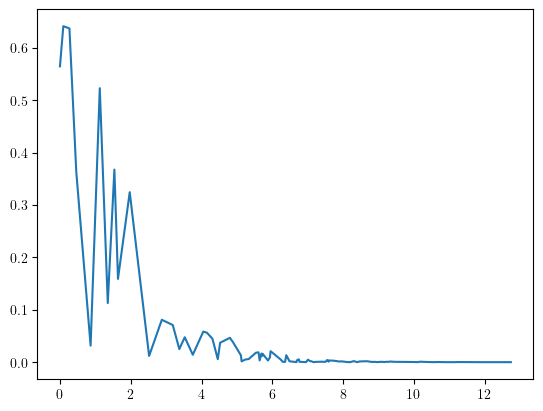

In [7]:
plt.plot(G.e, np.abs(s0_ft))
plt.show()

plt.plot(G.e, np.abs(s10_ft))
plt.show()

### 6) Evaluate the smoothness of the two graph signals, i.e. $\boldsymbol{x}^T\boldsymbol{L}\boldsymbol{x}$

In [8]:
s0_smooth = s0.T @ G.L @ s0
s10_smooth = s10.T @ G.L @ s10
print(s0_smooth, s10_smooth)

667.2695624018734 1.111847521592213


## Question 2. Synthetic and Real-world networks

### 1) Generate (or load) the following undirected graphs and plot them:
    
(a) An Erdos-Renyi graph with N = 50 and p = 0.1 using pygsp,
    
(b) A Ring graph with N = 50 using pygsp, and
    
(c) Cora3 citation network from PyTorch Geometric4.

In [9]:
import pygsp.graphs
import torch
import torch_geometric
import torch_geometric.datasets
import torch_geometric.transforms

# (a)
G_er = pygsp.graphs.ErdosRenyi(N= 50, p= 0.1)

# (b)
G_ring = pygsp.graphs.Ring(N= 50)

# (c)
cora_dataset = torch_geometric.datasets.Planetoid(root= "D:\Primary\Cornell Tech\Classes\ECE 5260 Graph Network Data Sci\Midterm 2", name= "Cora")
G_cora = cora_dataset[0]
print(G_cora.is_undirected())

True


### 2) Plot the graph frequencies of the Erdos-Renyi, PyGSP, and Cora graphs from the smallest to largest. Plot u2, u3, and u6 over the Cora graph

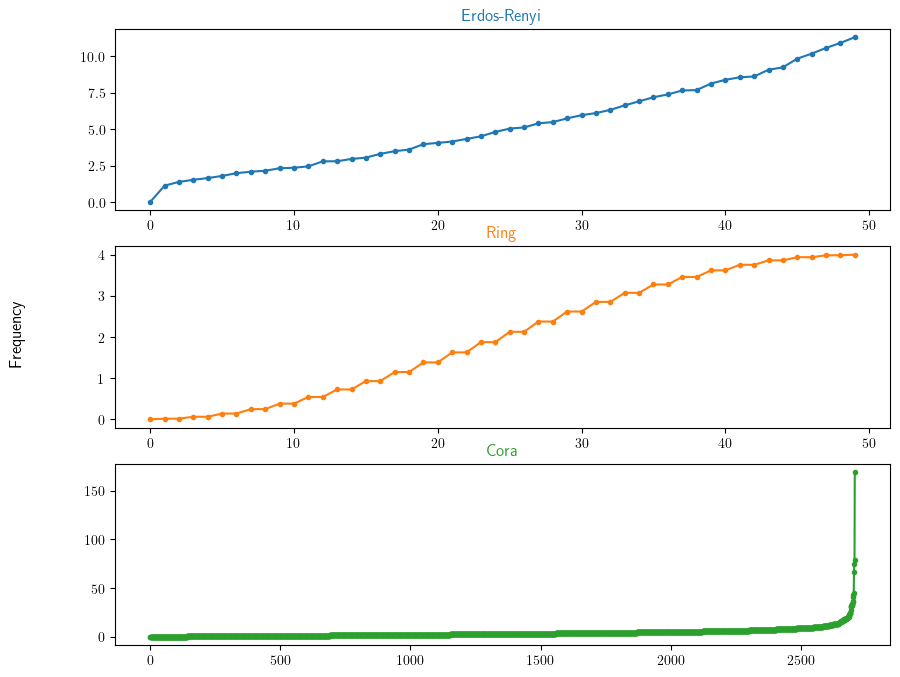

In [10]:
# TODO: Update to go from smallest frequency to largest frequency. 

import torch_geometric.datasets
import torch_geometric.utils
import torch

l_er, U_er = np.linalg.eig(G_er.L.toarray())
l_ring, U_ring = np.linalg.eig(G_ring.L.toarray())

L_edge_index, L_edge_weight = torch_geometric.utils.get_laplacian(G_cora.edge_index)

L_cora = torch.sparse_coo_tensor(L_edge_index, 
                                 L_edge_weight, 
                                 (G_cora.x.shape[0], G_cora.x.shape[0])).to_dense()
l_cora, U_cora = np.linalg.eig(L_cora.numpy())
l_cora_r, U_cora_r = l_cora.real, U_cora.real
idx_order = l_cora_r.argsort()
l_cora_s, U_cora_s = l_cora_r[idx_order], U_cora_r[:, idx_order]

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex= False)

axes[0].plot(
    range(len(l_er)),
    l_er[l_er.argsort()],
    marker= ".",
    color= "tab:blue",
    label= "Erdos-Renyi"
)
# axes[0].set_ylabel("Erdos-Renyi", color= "tab:blue")
axes[0].set_title("Erdos-Renyi", color= "tab:blue")

axes[1].plot(
    range(len(l_ring)),
    l_ring[l_ring.argsort()], 
    marker= ".", 
    color= "tab:orange",
    label= "Ring"
)
# axes[1].set_ylabel("Ring", color= "tab:orange")
axes[1].set_title("Ring", color= "tab:orange")

axes[2].plot(
    range(len(l_cora_s)), 
    l_cora_s, 
    marker= ".", 
    color= "tab:green",
    label= "Cora",
)
fig.supylabel("Frequency")

# axes[2].set_ylabel("", color= "tab:green")
axes[2].set_title("Cora", color= "tab:green")
plt.savefig("q2.2.png")
plt.show()


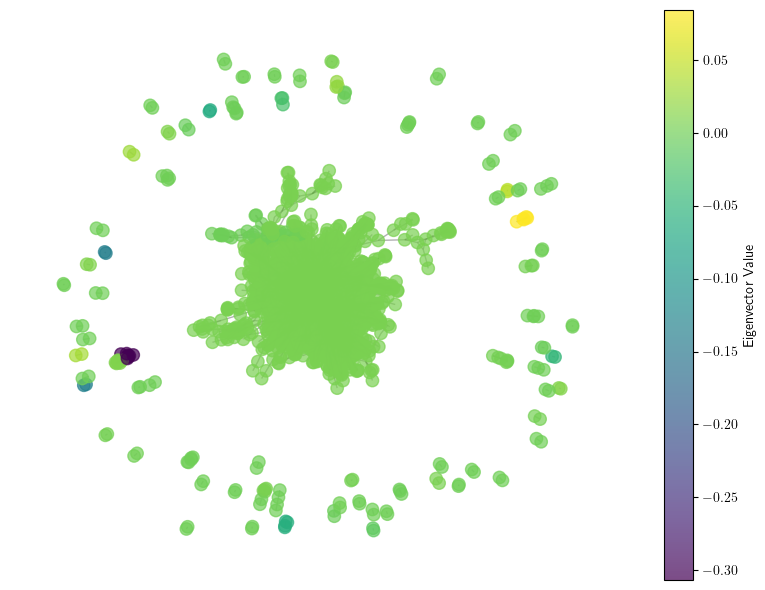

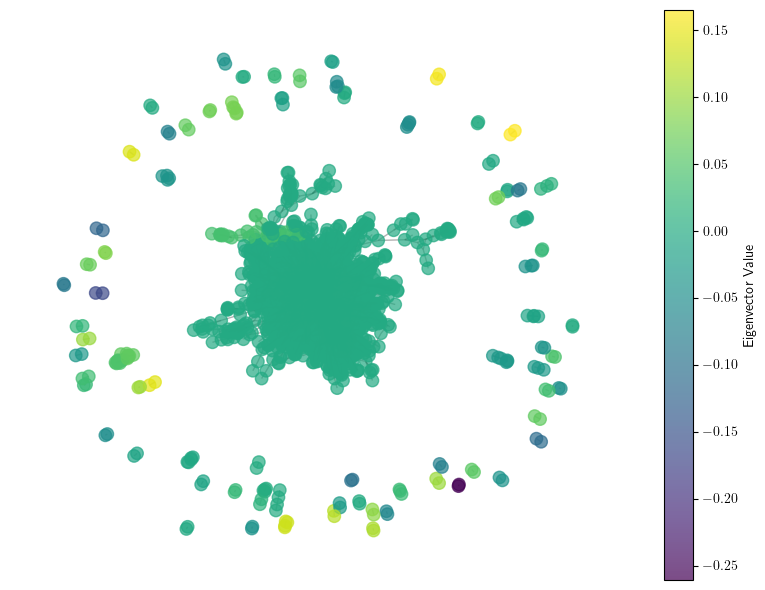

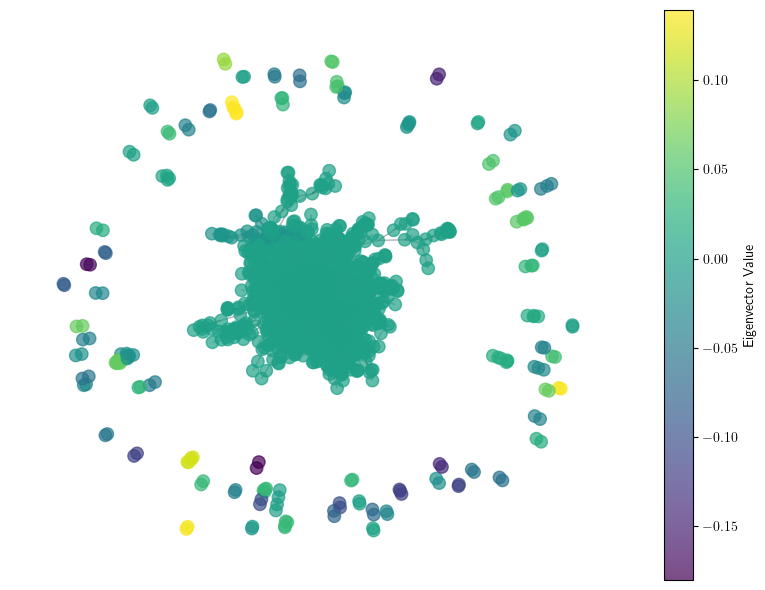

In [11]:
u2 = U_cora_s[:, 2]
u3 = U_cora_s[:, 3]
u6 = U_cora_s[:, 6]

G_cora_nx = torch_geometric.utils.to_networkx(G_cora, to_undirected= True)

pos_cora = nx.spring_layout(G_cora_nx, seed= 2025)

plt.figure(figsize=(8, 6))
nodes = nx.draw_networkx_nodes(
    G_cora_nx,
    pos_cora, 
    node_color= u2,
    cmap= 'viridis',
    node_size= 80,
    alpha= 0.7
)
nx.draw_networkx_edges(G_cora_nx, pos_cora, alpha= 0.3)
plt.colorbar(nodes, label= "Eigenvector Value")
plt.axis('off')
plt.tight_layout()
plt.savefig("q2.2.u2.png")

plt.figure(figsize=(8, 6))
nodes = nx.draw_networkx_nodes(
    G_cora_nx,
    pos_cora, 
    node_color= u3,
    cmap= 'viridis',
    node_size= 80,
    alpha= 0.7
)
nx.draw_networkx_edges(G_cora_nx, pos_cora, alpha= 0.3)
plt.colorbar(nodes, label= "Eigenvector Value")
plt.axis('off')
plt.tight_layout()
plt.savefig("q2.2.u3.png")

plt.figure(figsize=(8, 6))
nodes = nx.draw_networkx_nodes(
    G_cora_nx,
    pos_cora, 
    node_color= u6,
    cmap= 'viridis',
    node_size= 80,
    alpha= 0.7
)
nx.draw_networkx_edges(G_cora_nx, pos_cora, alpha= 0.3)
plt.colorbar(nodes, label= "Eigenvector Value")
plt.axis('off')
plt.tight_layout()
plt.savefig("q2.2.u6.png")
plt.show()

### 3) Compute the covariance matrix of the feature data of Cora and use t-SNE to obtain two principal components for clustering. Apply $K$-means to cluster the principal components into $K = 7$ classes and report the adjusted Rand index and the Silhouette score of the resulting labels.

In [29]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

x = cora_dataset[0].x.numpy()
y = cora_dataset[0].y.numpy()

print(f"Shape of feature data:\t{x.shape}\nShape of labels: {y.shape}")

x_m = np.mean(x, axis= 0)
x_c = x - x_m
cov = 1/(x.shape[0]-1) * x.T @ x
print(f"Shape of covariance matrix:\t{cov.shape}\n")

if np.allclose(cov, cov.T):
    print("Covariance is symmetric")
    cov_eval, cov_evec = np.linalg.eigh(cov)
else:
    print("Covariance is not symmetric")
    cov_eval, cov_evec = np.linalg.eig(cov)

cov_sort = cov_eval.argsort()[::-1]
cov_eval_s = cov_eval[cov_sort]
cov_evec_s = cov_evec[:, cov_sort]

pcs = 2
pc_v = cov_evec_s[:, :pcs]
x_pc = x_c @ pc_v

print(f"Shape of Covariance Principal Components:\t{x_pc.shape}\n")

K = 7
km = KMeans(n_clusters= K)
y_pred_cov = km.fit_predict(x_pc)
ari = adjusted_rand_score(y, y_pred_cov)
sil_score = silhouette_score(x, y_pred_cov)

print(f"Adjusted Rand Index (Covariance):\t{ari}")
print(f"Silhouette Score (Covariance)\t{sil_score}\n")

tsne = TSNE(n_components= 2)
principal_components = tsne.fit_transform(x)

print(f"Shape of t-SNE Principal Components:\t{principal_components.shape}\n")

y_pred_tsne = km.fit_predict(principal_components)

ari = adjusted_rand_score(y, y_pred_tsne)
sil_score = silhouette_score(x, y_pred_tsne)

print(f"Adjusted Rand Index (t-SNE):\t{ari}")
print(f"Silhouette Score (t-SNE):\t{sil_score}\n")


Shape of feature data:	(2708, 1433)
Shape of labels: (2708,)
Shape of covariance matrix:	(1433, 1433)

Covariance is symmetric
Shape of Covariance Principal Components:	(2708, 2)

Adjusted Rand Index (Covariance):	0.026174209164604282
Silhouette Score (Covariance)	-0.06205783411860466

Shape of t-SNE Principal Components:	(2708, 2)

Adjusted Rand Index (t-SNE):	0.10130754491914598
Silhouette Score (t-SNE):	0.002974314847961068



### 4) Low-Pass Filter

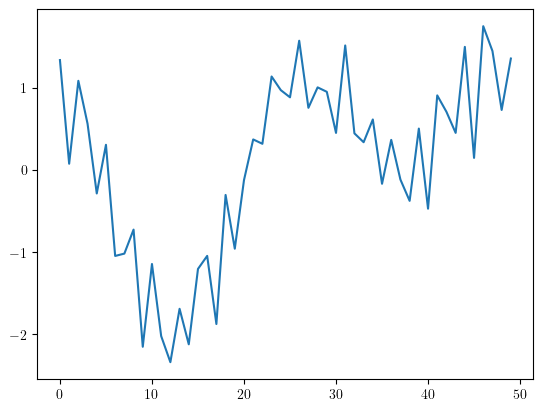

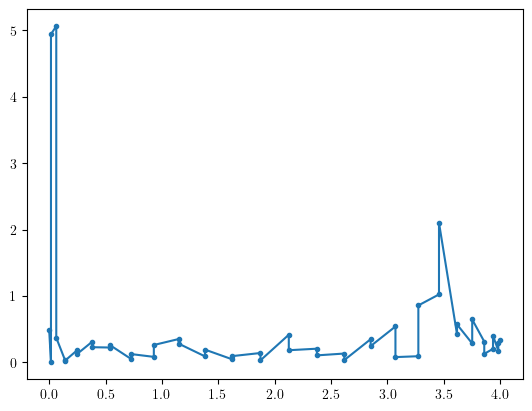

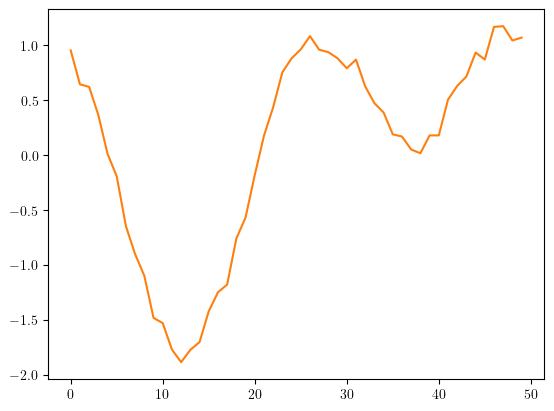

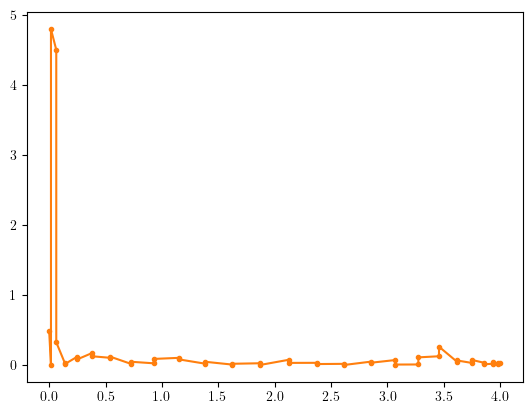

In [ ]:
import pygsp.filters

def lp_filter(freq, alpha= 2):
    return 1/(1+alpha*freq)

# a)

N = 50
inp = np.linspace(-np.pi, np.pi, N)
x = np.sin(inp)+np.cos(2*inp)+0.5*np.cos(30*inp)
x_noisy = x + np.random.uniform(-0.4, 0.4, N)

# b)
plt.plot(np.arange(N), x_noisy, color= "tab:blue")
plt.show()

# c)
G_ring.compute_fourier_basis()
x_gft_n = G_ring.gft(x_noisy)

plt.plot(G_ring.e, np.abs(x_gft_n), '.-', color= "tab:blue")
plt.show()

# d)
g = pygsp.filters.Filter(G_ring, lp_filter)
x_denoised = g.filter(x_noisy, method= 'exact')

plt.plot(np.arange(N), x_denoised, color= "tab:orange")
plt.show()

x_gft_d = G_ring.gft(x_denoised)
plt.plot(G_ring.e, np.abs(x_gft_d), '.-', color= "tab:orange")
plt.show()

## Question 3

### 1) Build a two-layer Chebyshev Graph Neural Network class using PyTorch Geometric’s Chebyshev spectral graph convolutional operator, `ChebConv`. For the first layer, the input channel is the number of features in the dataset, the output channel is 40, and the order of the Graph Shift Operator (GSO) is $K = 5$. For the second layer, the input channel is 40, and the output channel is the number of label classes in the dataset. In the forward function, use `relu` as the first layer activation function and `log_softmax` for the output activation function to obtain the predicted labels.

In [48]:
import torch.nn.functional as F
from torch_geometric.nn import ChebConv

class GCN(torch.nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = ChebConv(cora_dataset.num_features, 40, K= 5)
        self.conv2 = ChebConv(40, cora_dataset.num_classes, K= 5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.log_softmax(x, dim= 1)

        return x
    
    


### 2) Train your graph neural network using the Adam optimizer with a learning rate of $0.01$ and weight decay of $5e−4$. You may use `torch.nn.functional.nll_loss` or any other loss functions that are suitable for your GCN model as your loss function. Plot your training loss with the epoch number on the $x$-axis.

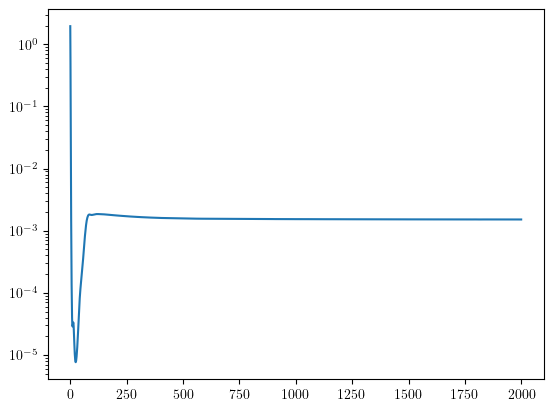

Accuracy:	0.7820


In [53]:
l_rate = 0.01
w_decay = 5e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GCN().to(device)
data = cora_dataset[0].to(device)
optimizer = torch.optim.Adam(model.parameters(), lr= l_rate, weight_decay= w_decay)

n_epochs = 2000
epochs = np.arange(n_epochs)
train_loss = np.zeros((n_epochs,))

model.train()
for epoch in range(n_epochs):
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    train_loss[epoch] = loss

plt.plot(epochs, train_loss)
plt.yscale("log")
plt.show()

### 3) Test your graph neural network to report the accuracy. Visualize the graph with node labels for both the ground truth and the predicted ones.

In [54]:
model.eval()
pred = model(data).argmax(dim= 1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print(f"Accuracy:\t{acc:.4f}")

Accuracy:	0.7820
